In [1]:
%pip install spacy
%pip install ftfy
%pip install datasets
%pip install torch
%pip install seqeval
%pip install 'accelerate>=1.1.0'
%pip install tqdm
%pip install evaluate
%pip install transformers 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 86.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.9/839.9 kB 30.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 84.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [spacy]m21/22 [spacy]]n-it-py]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 9.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 76.9 MB/s  0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.3.0
    Uninstalling fsspec-2026.3.0:
      Successfully uninstalled fsspec-2026.3.0━━━━━━━

In [111]:
import pandas as pd
import numpy as np
import zipfile
import re
import spacy
import seaborn as sns
import matplotlib.pyplot as plt 
import evaluate
import torch
import accelerate
import ftfy
import random
import ast

from collections import Counter
from tqdm import tqdm
from collections import defaultdict
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification
from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)


# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

### Téléchargement des données et preprocessing

In [3]:
data = pd.read_csv("data/metadonnees.csv")

/tmp/ipykernel_1753/2130726195.py:1: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/metadonnees.csv")


In [4]:
data["date"] = pd.to_datetime(data["date"])

data[["annee","mois","jour"]] = data["date"].apply(
    lambda x: pd.Series([x.year, x.month, x.day])
)
#print("Nombre de professions par années :", data["annee"].value_counts().sort_index())

In [68]:
data.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations',
       'annee', 'mois', 'jour'],
      dtype='object')

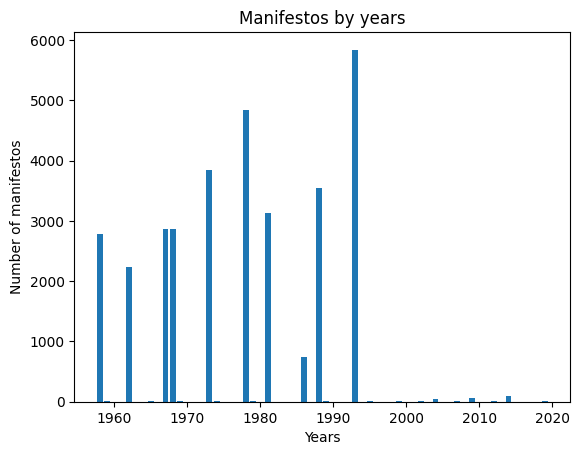

In [22]:
counts = data["annee"].value_counts().sort_index()

plt.bar(counts.index, counts.values)

plt.title("Manifestos by years")
plt.xlabel("Years")
plt.ylabel("Number of manifestos")

plt.savefig("figures/Nombre de profession de foi par an.png")
#plt.show()

In [42]:
# Export des professions de foi de l'année 1993
zip_path = "data/legislatives.zip"

docs = []

with zipfile.ZipFile(zip_path) as z:
    for file in z.namelist():
        if file.endswith(".txt"):
            with z.open(file) as f:
                text = f.read().decode("utf-8", errors="ignore")
                docs.append({"file": file, "text": text})

transcriptions = pd.DataFrame(docs)

transcriptions = transcriptions.assign(
    id=transcriptions["file"].str.extract(r'([^/]+)\.txt'),
    annee=transcriptions["file"].str.extract(r'text_files/(\d{4})')
)
transcriptions = transcriptions.drop(columns = ["file"])

transcriptions = transcriptions.merge(data[['id', 'titulaire-soutien', 'titulaire-sexe']], on='id', how='left')


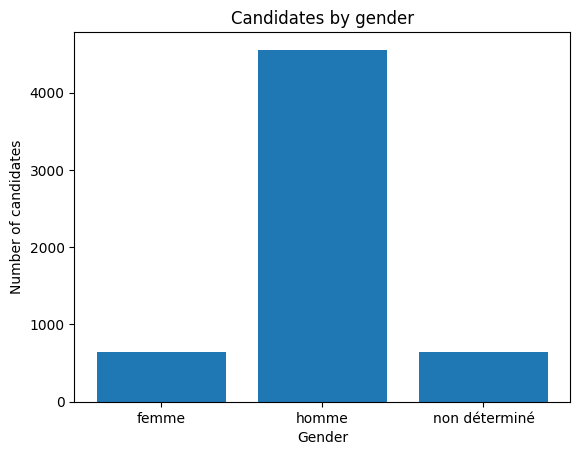

In [21]:
sex = transcriptions["titulaire-sexe"].value_counts().sort_index()

plt.bar(sex.index, sex.values)

plt.title("Candidates by gender")
plt.xlabel("Gender")
plt.ylabel("Number of candidates")

plt.savefig("figures/Répartition de candidats par genre.png")
#plt.show()

In [43]:
pd.set_option('display.max_colwidth', None)
extrait = transcriptions.sample()

In [44]:
def nettoyage_profession_foi(texte):
    if not isinstance(texte, str):
        return ""

    texte = texte.replace('\u2019', "'").replace('\u2018', "'").replace('\u2032', "'")

    # Suppression des symboles
    texte = re.sub(r'[\u2600-\u26FF\u2700-\u27BF\u25A0-\u25FF]', ' ', texte)

    texte = re.sub(r'(\w+)-\n(\w+)', r'\1\2', texte)
    
    texte = re.sub(
        r'^REPUBLIQUE\s+FRANCAISE\s*-.*$',
        '',
        texte,
        flags=re.IGNORECASE | re.MULTILINE
    )

    # Suppression des "ELECTIONS..."
    texte = re.sub(r'ELECTIONS.*?\d{4}', '', texte, flags=re.IGNORECASE)

    # Suppression des "Suppléant : ..."
    texte = re.sub(r'Suppl[ée]ant\s*:.*', '', texte, flags=re.IGNORECASE)

    # Suppression des noms de candidats de la liste
    texte = re.sub(
        r'^[A-ZÀ-ÖØ-Ý][a-zà-öø-ÿ\-]+\s+[A-ZÀ-ÖØ-Ý]{2,}.*$',
        '',
        texte,
        flags=re.MULTILINE
    )

    texte = re.sub(
        r'^[A-ZÀ-ÖØ-Ý][a-zà-öø-ÿ\-]+\s+[A-ZÀ-ÖØ-Ý][a-zà-öø-ÿ\-]+(?:,\s*[A-ZÀ-ÖØ-Ý][a-zà-öø-ÿ\-]+\s+[A-ZÀ-ÖØ-Ý][a-zà-öø-ÿ\-]+)+$',
        '',
        texte,
        flags=re.MULTILINE
    )

    texte = re.sub(
        r'^[A-Z\s]{5,}$',
        '',
        texte,
        flags=re.MULTILINE
    )

    # "VU LES CANDIDATS"
    texte = re.sub(r'VU LES CANDIDATS', '', texte, flags=re.IGNORECASE)

    # Suppression des sources Sciences Po / CEVIPOF
    texte = re.sub(
        r'^.*(Sciences Po|CEVIPOF|Archives).*$',
        '',
        texte,
        flags=re.IGNORECASE | re.MULTILINE
    )

    texte = re.sub(r'^\s*[-•·]\s*', '', texte, flags=re.MULTILINE)

    texte = re.sub(r'^\s*\d+\s*$', '', texte, flags=re.MULTILINE)

    texte = re.sub(r'[ \t]+', ' ', texte)
    texte = re.sub(r'\n{3,}', '\n\n', texte)

    return texte.strip()

On ne veut pas nécessairement retirer les stopwords, car l'on veut à terme regarder dans quelle mesure les candidats s'adressent à leurs électeurs. En particulier, les pronoms personnels ("vous"), les déterminants possessifs ("vos", "nos") sont importants dans ce cas.

In [48]:
# Test 
extrait_nettoye = nettoyage_profession_foi(extrait['text'].iloc[0])
print(extrait_nettoye)

MARNE ECOLOGIE 6° circonscription de la MARNE

Pharmacienne, Membre de la Société Nationale de la Protection de la Nature, Chargée de mission à l'Oeuvre d'Assistance aux bêtes d'abattoirs, 30 ans d'écologie concrète sans politique ni média.
N'ayant jamais appartenu à un parti, je revendique une complète indépendance politique. Au sein de Marne Ecologie, avec mon suppléant Christian Collin, mon parti c'est la France, mon idéologie c'est le bon sens.
Les erreurs d'orientation ont coûté cher aux Français. Les dépenses ostentatoires ont eu priorité sur des besoins vitaux, et les sinistrés des inondations attendent toujours. Comment peut-on admettre que le montant de l'impôt sur le revenu des Français soit dévoré par le paiement des intérêts de notre dette? Alors n'y aurait-il rien à faire? Si! Voici quelques objectifs pleins de bon sens. Ils relèvent de la logique écologique.
Le respect de la Nature:
Il faut cesser de détruire la Nature, les ressources, l'eau, les sols. La qualité de l'air

In [ ]:
transcriptions['texte_nettoye'] = transcriptions['text'].apply(nettoyage_profession_foi)

### Diversité lexicale

In [59]:
def ttr(text):
    if not isinstance(text, str):
        return 0

    words = re.findall(r'\w+', text.lower())

    n = len(words)
    if n == 0:
        return 0

    v = len(set(words))

    return v / n

In [60]:
# Test 
extrait_lexique = ttr(extrait['text'].iloc[0])
print(extrait_lexique)

0.4721115537848606


In [61]:
transcriptions['diversite_lexicale'] = transcriptions['text'].apply(ttr)

In [70]:
transcriptions = transcriptions.merge(
    data[["id", "departement", "titulaire-profession"]],
    on="id",
    how="left"
)

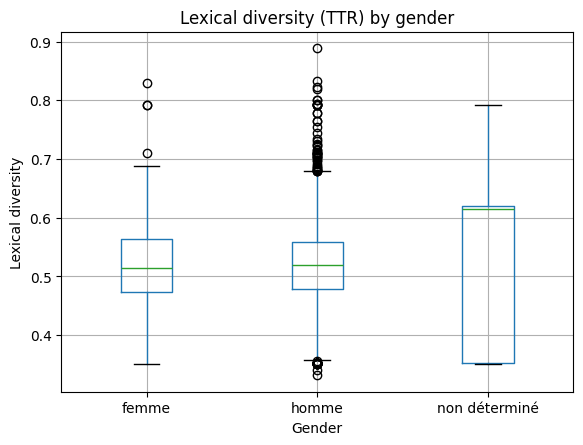

In [ ]:
transcriptions_clean = transcriptions.dropna(subset=["titulaire-sexe", "diversite_lexicale"])

transcriptions_clean.boxplot(column="diversite_lexicale", by="titulaire-sexe")

plt.title("Lexical diversity (TTR) by gender")
plt.suptitle("") 
plt.xlabel("Gender")
plt.ylabel("Lexical diversity")

plt.savefig("figures/Lexical Diversity")
# plt.show()

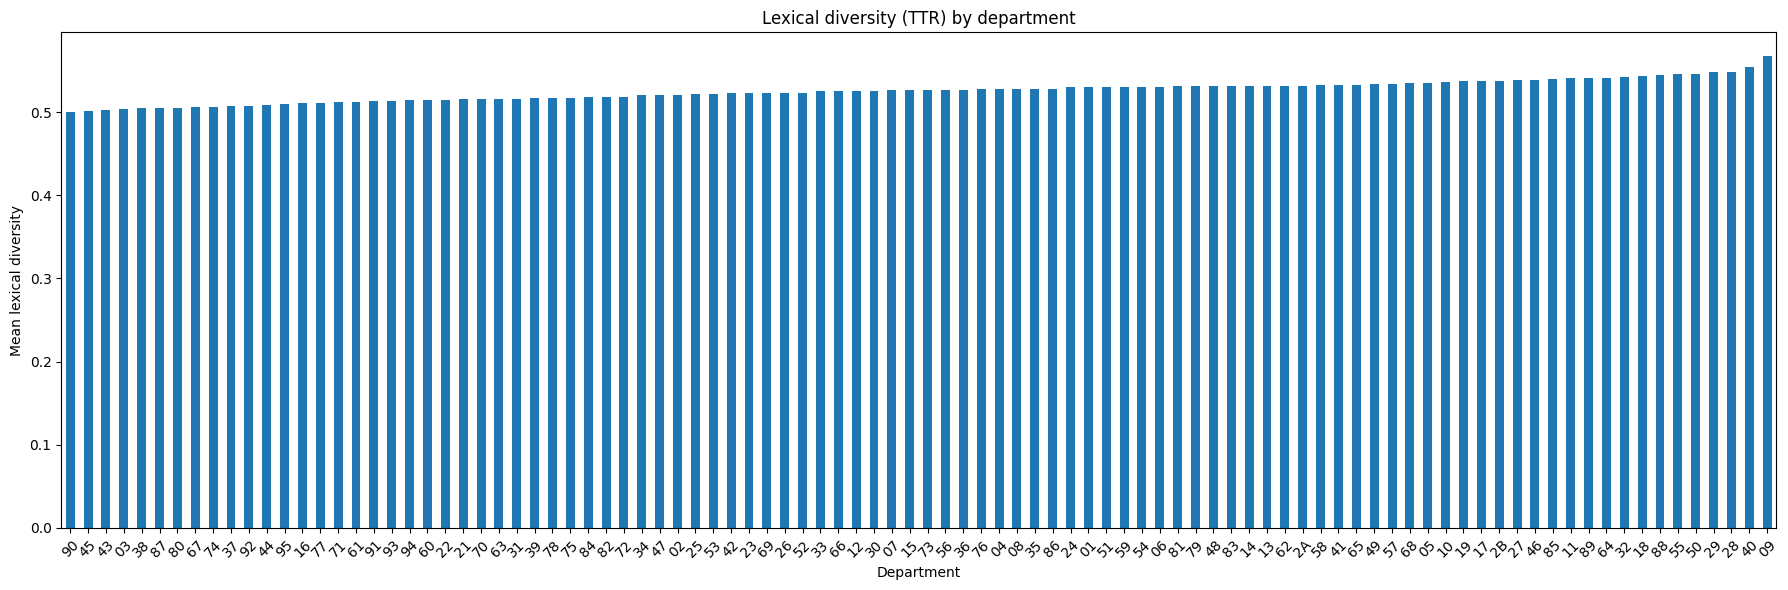

In [100]:
# Illisible
moyennes = transcriptions.groupby("departement")["diversite_lexicale"].mean().sort_values()
plt.figure(figsize=(18, 6))
ax = moyennes.plot(kind="bar")

ax.set_title("Lexical diversity (TTR) by department")
ax.set_ylabel("Mean lexical diversity")
ax.set_xlabel("Department")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/Lexical Diversity Dptm")

In [99]:
moyennes = transcriptions.groupby("titulaire-profession")["diversite_lexicale"].mean().sort_values(ascending=False)
moyennes = pd.DataFrame(moyennes)
moyennes["rang"] = moyennes["diversite_lexicale"].rank()
pd.concat([
    moyennes.head(),
    moyennes.tail()
])

,diversite_lexicale,rang
titulaire-profession,,
radio,0.764706,1204.0
commerçant restaurateur,0.708333,1203.0
responsable centre télécom,0.677419,1202.0
commerçante alimentation,0.664430,1201.0
responsable financier,0.658986,1200.0
chef d'entreprise;profession libérale,0.351774,5.0
employée hôpitaux,0.351104,3.0
ouvrier monteur,0.351104,3.0
électro-technicien automobile,0.351104,3.0


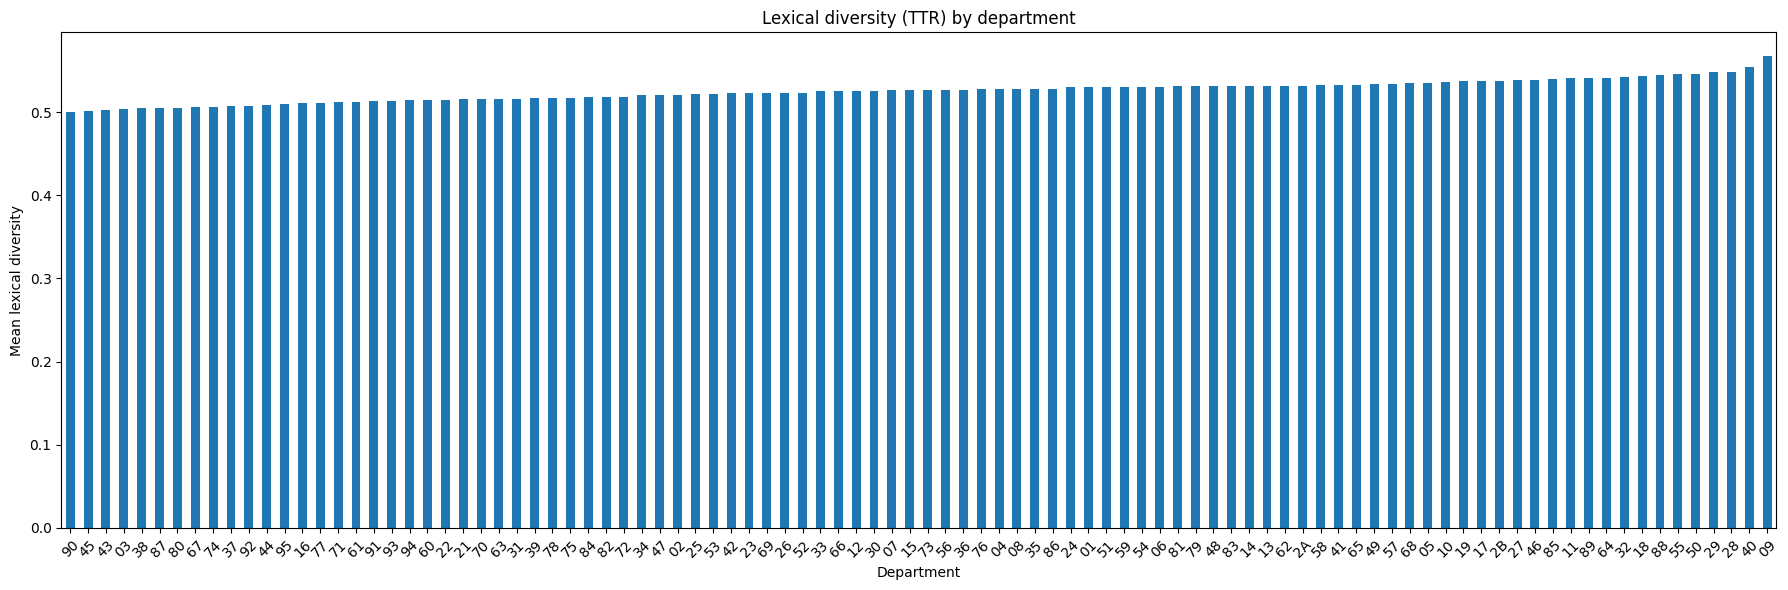

In [80]:
moyennes = transcriptions.groupby("departement")["diversite_lexicale"].mean().sort_values()
plt.figure(figsize=(18, 6))
ax = moyennes.plot(kind="bar")

ax.set_title("Lexical diversity (TTR) by department")
ax.set_ylabel("Mean lexical diversity")
ax.set_xlabel("Department")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/Lexical Diversity Dptm")
#plt.show()

### Analyse des pronoms

In [ ]:
# Tokenization
# Au préalable, télécharger : python -m spacy download fr_core_news_lg
nlp = spacy.load("fr_core_news_lg")  

def tokenizer_et_pos(texte_propre):
    """Prend un texte déjà nettoyé et en minuscules, retourne tokens et POS"""
    doc = nlp(texte_propre)
    return [(token.text, token.pos_) for token in doc if not token.is_space]

In [50]:
# Test
token_extrait = tokenizer_et_pos(extrait_nettoye)

print(token_extrait[:15])

[('MARNE', 'PROPN'), ('ECOLOGIE', 'NOUN'), ('6', 'NUM'), ('°', 'NOUN'), ('circonscription', 'NOUN'), ('de', 'ADP'), ('la', 'DET'), ('MARNE', 'PROPN'), ('Pharmacienne', 'ADJ'), (',', 'PUNCT'), ('Membre', 'NOUN'), ('de', 'ADP'), ('la', 'DET'), ('Société', 'PROPN'), ('Nationale', 'ADJ')]


In [ ]:
textes = transcriptions['texte_nettoye'].tolist()
ids = transcriptions['id'].tolist()  # adapte selon tes colonnes


resultats = []

for idx, doc in enumerate(nlp.pipe(textes, batch_size=50, disable=["tagger", "ner"])):
    
    for sent_num, sent in enumerate(doc.sents):
        
        comptes = {'je': 0, 'nous': 0, 'vous': 0, 'on': 0, 'total': 0}
        total_mots = 0
        
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            total_mots += 1
            
            if token.pos_ == "PRON":
                lemme = token.text.lower()
                if lemme in ['je', 'moi', 'me', "m'", "mes", "ma", "mon", "mien"]:
                    comptes['je'] += 1
                elif lemme in ['nous', 'notre', 'nos', "nôtres"]:
                    comptes['nous'] += 1
                elif lemme in ['vous', 'votre', 'vos', "vôtres"]:
                    comptes['vous'] += 1
                elif lemme == 'on':
                    comptes['on'] += 1
                comptes['total'] += 1
        
        ratios = {}
        for key in ['je', 'nous', 'vous', 'on']:
            ratios[f'{key}_p1000'] = (comptes[key] / total_mots * 1000) if total_mots > 0 else 0
        
        total_je_nous = comptes['je'] + comptes['nous']
        ratios['ratio_je_nous'] = comptes['je'] / total_je_nous if total_je_nous > 0 else 0

        total_vous_je = comptes['je'] + comptes['vous'] + comptes["nous"]
        ratios['ratio_vous_je'] = comptes['vous'] / total_vous_je if total_vous_je > 0 else 0
        
        resultats.append({
            'source_id': ids[idx],
            'phrase_num': sent_num,
            'phrase': sent.text.strip(),
            'nb_mots': total_mots,
            **comptes,
            **ratios
        })


In [16]:
pronoms_stats = pd.DataFrame(resultats)
pronoms_stats = pronoms_stats.drop_duplicates(subset='phrase')
pronoms_stats = pronoms_stats[pronoms_stats['nb_mots'] >= 5]

pronoms_stats = pronoms_stats.merge(
    transcriptions[['id', 'titulaire-sexe']],
    left_on='source_id',
    right_on='id',
    how='left'
).drop(columns='id')

In [17]:
cols_scores = ['je_p1000', 'nous_p1000', 'vous_p1000', 'on_p1000', 'ratio_je_nous', 'ratio_vous_je']
agg_stats_sexe = pronoms_stats.groupby('titulaire-sexe')[cols_scores].agg(['mean', 'std']).reset_index()

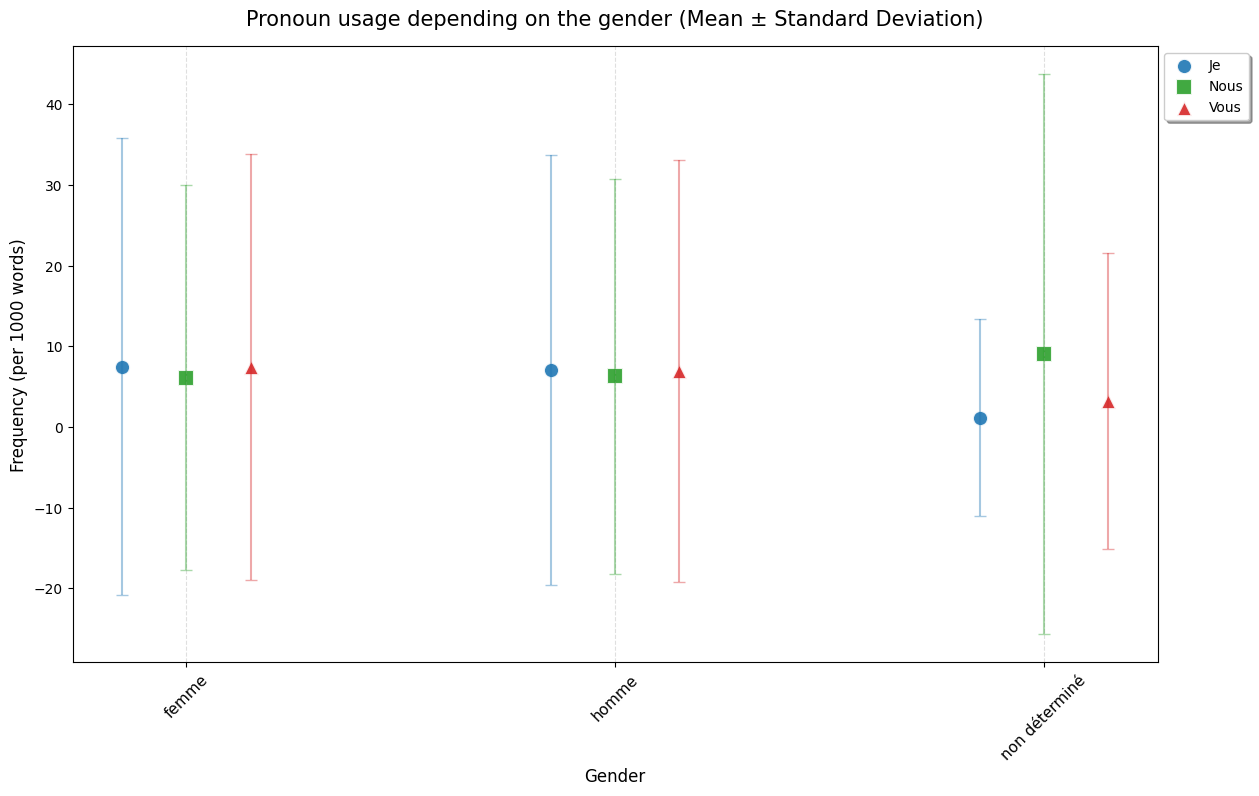

In [ ]:
df = agg_stats_sexe.copy()
sexe = df['titulaire-sexe']
y_pos = np.arange(len(sexe))  

plt.figure(figsize=(14, 8))

offset = 0.15 

plt.scatter(
    y_pos - offset, 
    df['je_p1000']['mean'], 
    s=120,                
    c='#1f77b4',          
    marker='o',          
    label='Je', 
    edgecolors='white',   
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Je
plt.errorbar(y_pos - offset, df['je_p1000']['mean'], yerr=df['je_p1000']['std'], 
             fmt='none', ecolor='#1f77b4', alpha=0.4, capsize=4)

plt.scatter(
    y_pos, 
    df['nous_p1000']['mean'], 
    s=120, 
    c='#2ca02c', 
    marker='s',           
    label='Nous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Nous
plt.errorbar(y_pos, df['nous_p1000']['mean'], yerr=df['nous_p1000']['std'], 
             fmt='none', ecolor='#2ca02c', alpha=0.4, capsize=4)


plt.scatter(
    y_pos + offset, 
    df['vous_p1000']['mean'], 
    s=120, 
    c='#d62728', 
    marker='^',           
    label='Vous', 
    edgecolors='white', 
    linewidth=1.5,
    alpha=0.9
)
# Barres d'erreur pour Vous
plt.errorbar(y_pos + offset, df['vous_p1000']['mean'], yerr=df['vous_p1000']['std'], 
             fmt='none', ecolor='#d62728', alpha=0.4, capsize=4)

plt.title("Pronoun usage depending on the gender (Mean ± Standard Deviation)", fontsize=15, pad=15)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Frequency (per 1000 words)", fontsize=12)


plt.xticks(y_pos, sexe, fontsize=11, rotation = 45)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)

plt.savefig("figures/Usage des pronoms en fonction du sexe.png")
#plt.show()

### Identification de la fonction dans la phrase 

Les quelques cellules ci-dessous tentent d'identifier la fonction des pronoms 'je', 'nous', 'vous' lorsqu'ils sont utilisés (sujet VS objet), ainsi que le type de verbe qui les succède ou précède (action VS état).

In [28]:
# Verbes statifs
VERBES_ETAT = {'être', 'paraître', 'sembler', 'demeurer', 'rester', 'devenir', 'voir', 'vivre'
               'devoir', 'pouvoir', 'vouloir', 'falloir', 'savoir', 'croire', 'penser', 'appeler'}

VERBES_MODAUX = {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire', 'laisser', 'sembler', 'paraître'}


In [29]:
# Prend environ 3-4 min 
textes = transcriptions['texte_nettoye'].tolist()

results = []

for doc in nlp.pipe(textes, batch_size=50, disable=["ner"]):
    
    stats = {'je': defaultdict(int), 'nous': defaultdict(int), 'vous': defaultdict(int)}
    mapping_pronom = {
        'je': ['je', "j'", 'moi', 'me', "m'"],
        'nous': ['nous'],
        'vous': ['vous']
    }

    for token in doc:
        if token.is_space or token.is_punct: 
            continue
        
        pronom_type = None
        if token.pos_ == "PRON":
            for p_type, formes in mapping_pronom.items():
                if token.text.lower() in formes or token.lemma_.lower() in formes:
                    pronom_type = p_type
                    break
        
        if pronom_type:
            verbe = None
            fonction = None
            
            if token.dep_ in ("nsubj", "nsubjpass"):
                fonction = "sujet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                fonction = "objet"
                if token.head.pos_ in ("VERB", "AUX"): 
                    verbe_cible = token.head

            lemme_tete = verbe_cible.lemma_.lower() # Ex type : Nous devons agir : on veut identifier agir et non devoir
            if lemme_tete in VERBES_MODAUX: # {'devoir', 'pouvoir', 'vouloir', 'aller', 'faire'}
                for child in verbe_cible.children:
                    if child.pos_ == "VERB":
                        verbe = child # On remplace le modal par le verbe enfant
                        break
            else :
                verbe = verbe_cible
                
            if verbe:
                v_lem = verbe.lemma_.lower()
                type_v = "etat" if v_lem in VERBES_ETAT else "action"
                stats[pronom_type][f"{fonction}_{type_v}"] += 1
                stats[pronom_type][f"{fonction}"] +=1
                stats[pronom_type][f"{type_v}"] +=1

    row = {}
    for p in ['je', 'nous', 'vous']:
        for k, v in stats[p].items():
            row[f"{p}_{k}"] = v
    
    for p in ['je', 'nous', 'vous']:
        for f in ['sujet', 'objet']:
            for t in ['action', 'etat']:
                key = f"{p}_{f}_{t}"
                if key not in row: 
                    row[key] = 0
                
    results.append(row)

df_structure = pd.DataFrame(results)

# Concaténation avec les infos originales
transcriptions_structure_test = pd.concat([transcriptions[['id']], df_structure], axis=1)

### Etude du pronom '*vous*' seulement

In [30]:
def _cherche_relation_je_nous(vous_token, pronoms_je_nous: set) -> str | None:
    """
    Cherche si je/nous est relié à 'vous' dans la même phrase.
    
    Logique :
    - Si 'vous' est COD/COI → cherche le sujet du même verbe
    - Si 'vous' est sujet   → cherche un autre sujet coordonné (nous et vous)
    """
    verbe = vous_token.head
    
    # Parcourt les enfants du même verbe
    for sibling in verbe.children:
        if sibling.text.lower() in pronoms_je_nous:
            if sibling.dep_ in ("nsubj", "nsubj:pass"):
                return sibling.text.lower() 
    
    # Cherche aussi dans les tokens de la phrase entière
    for token in vous_token.sent:
        if token.text.lower() in pronoms_je_nous:
            if token.head == verbe:
                return token.text.lower() 
    return None

In [34]:
def analyser_vous(textes: list[str], textes_id) -> list[dict]:
    """
    Pour chaque occurrence de 'vous' dans les textes,
    retourne sa fonction syntaxique et si elle est reliée à je/nous.
    """
    resultats = []
    
    dep_to_fonction = {
        "nsubj" : "sujet",
        "nsubj:pass" : "sujet",
        "expl:subj" : "sujet",
        "obj" : "COD",
        "expl:comp" : "COD",
        "iobj" : "COI",
        "obl" : "COI",
        "obl:arg" : "COI",
        "obl:mod" : "COI",
        "obl:agent" : "COI",
        "amod" : "COI",
        "advmod" : "COI",
        "nmod" : "complément du nom",
        "appos" : "apposition",     # "vous qui..."
        "conj" : "coordination", # "vous et eux"
        "dep" : "autre/indéterminé",
    }
    
    pronoms_je_nous = {"je", "j'", "nous", "j", "me", "moi", "m'"}

    pipe = nlp.pipe(textes, batch_size=64, disable=["ner"])
    
    for i, doc in enumerate(pipe):

        idx_original = textes_id[i]
        
        for sent in doc.sents:
            for token in sent :
                if token.text.lower() != "vous":
                    continue

                fonction = dep_to_fonction.get(token.dep_, "autre/indéterminé")
                relie_a = _cherche_relation_je_nous(token, pronoms_je_nous)
                
                resultats.append({
                    "texte_id"    : idx_original,
                    "phrase"      : sent.text.strip(),
                    "vous_index"  : token.i,
                    "verbe"       : token.head.text if token.head != token else None,  # Le mot dont vous dépend
                    "dep_raw"     : token.dep_,  # Fonction brute de spacy 
                    "fonction"    : fonction,  # Fonction de vous dans la phrase telle qu'on l'a encodée
                    "relie_je_nous": relie_a    # None si pas de relation
                })
    
    return resultats

In [35]:
resultats_vous = analyser_vous(textes, transcriptions["id"])

df_vous = pd.DataFrame(resultats_vous)

print("Nombre de fonctions : ", df_vous['fonction'].value_counts())
print("")
print("Co-occurences de je/nous reliés à vous :", df_vous['relie_je_nous'].value_counts(dropna=False))

Nombre de fonctions :  fonction
sujet                12757
COI                   8329
COD                   1965
autre/indéterminé     1114
complément du nom      911
coordination           162
apposition              19
Name: count, dtype: int64

Co-occurences de je/nous reliés à vous : relie_je_nous
None    20241
je       2843
nous     1133
m'        436
moi       221
me        217
j'        164
j           2
Name: count, dtype: int64


In [36]:
phrases_uniques = df_vous["phrase"].value_counts()
phrases_uniques = phrases_uniques[phrases_uniques == 1].index
df_vous_dedup = df_vous[df_vous["phrase"].isin(phrases_uniques)]

In [38]:
agg_df_vous = df_vous_dedup.groupby([ 'fonction']).size().unstack(fill_value=0).reset_index()
agg_df_vous['non_sujet'] = agg_df_vous["COD"]+agg_df_vous["COI"]+agg_df_vous["apposition"]+agg_df_vous["autre/indéterminé"]+agg_df_vous["complément du nom"]+agg_df_vous["coordination"]
agg_df_vous["prop_sujet"] = agg_df_vous["sujet"]/(agg_df_vous["sujet"]+agg_df_vous["non_sujet"])
agg_df_vous["prop_non_sujet"] = 1-agg_df_vous["prop_sujet"]
#agg_stats.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in agg_stats.columns]

ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.base.Index'> was passed

### Etude du pronom 'je'

In [22]:
VERBES_MODALITE = {"pouvoir", "devoir", "falloir", "vouloir"}

def get_verbe_principal(token):
    """
    Retourne le verbe lexical principal :
    - si la tête est un AUX, cherche le VERB dans ses enfants
    - sinon retourne la tête si c'est un VERB/AUX
    """
    head = token.head
    if head == token:
        return None
    if head.pos_ == "VERB":
        if head.lemma_.lower() in VERBES_MODALITE :
            for child in head.children:
                if child.pos_=="VERB":
                    return child.lemma_
            return head.lemma_
        else : 
            return head.lemma_
    if head.pos_ == "AUX":
        # Chercher un VERB dépendant de cet auxiliaire
        for child in head.children:
            if child.pos_ == "VERB":
                return child.lemma_
        # Aucun VERB trouvé, retourner l'AUX quand même
        return head.lemma_
    return None

def analyser_je(textes: list[str], textes_id, parti_pol, sexe, pronoms) -> list[dict]:
    """
    Pour chaque occurrence de 'vous' dans les textes,
    retourne sa fonction syntaxique et si elle est reliée à je/nous.
    """
    resultats = []
    
    dep_to_fonction = {
        "nsubj" : "sujet",
        "nsubj:pass" : "sujet",
        "expl:subj" : "sujet",
        "obj" : "COD",
        "expl:comp" : "COD",
        "iobj" : "COI",
        "obl" : "COI",
        "obl:arg" : "COI",
        "obl:mod" : "COI",
        "obl:agent" : "COI",
        "amod" : "COI",
        "advmod" : "COI",
        "nmod" : "complément du nom",
        "appos" : "apposition",     # "vous qui..."
        "conj" : "coordination", # "vous et eux"
        "dep" : "autre/indéterminé",
    }


    pipe = nlp.pipe(textes, batch_size=64, disable=["ner"])
    
    for i, doc in enumerate(pipe):

        idx_original = textes_id[i]
        parti_pol_original = parti_pol[i]
        sexe_original = sexe[i]
        
        for sent in doc.sents:
            for token in sent :
                if token.text.lower() not in pronoms:
                    continue

                fonction = dep_to_fonction.get(token.dep_, "autre/indéterminé")

                resultats.append({
                    "texte_id" : idx_original,
                    "phrase" : sent.text.strip(),
                    "pron_index" : token.i,
                    "verbe" : get_verbe_principal(token),
                    "fonction" : fonction,  # Fonction de vous dans la phrase telle qu'on l'a encodée
                    "parti_politique" : parti_pol_original,
                    "sexe" : sexe_original
                })
    
    return resultats

In [ ]:
pronoms_je_nous = {"je", "j'", "nous", "me", "moi", "m'"}

resultats_je = analyser_je(textes, 
                           transcriptions["id"], 
                           transcriptions["titulaire-sexe"],
                           pronoms_je_nous)

df_je = pd.DataFrame(resultats_je)

print("Nombre de fonctions : ", df_je['fonction'].value_counts())

Nombre de fonctions :  fonction
sujet                33838
COI                   9075
COD                   5275
autre/indéterminé     1367
complément du nom      537
coordination           341
apposition              13
Name: count, dtype: int64


In [24]:
phrases_uniques = df_je["phrase"].value_counts()
phrases_uniques = phrases_uniques[phrases_uniques == 1].index

df_je_dedup = df_je[df_je["phrase"].isin(phrases_uniques)]

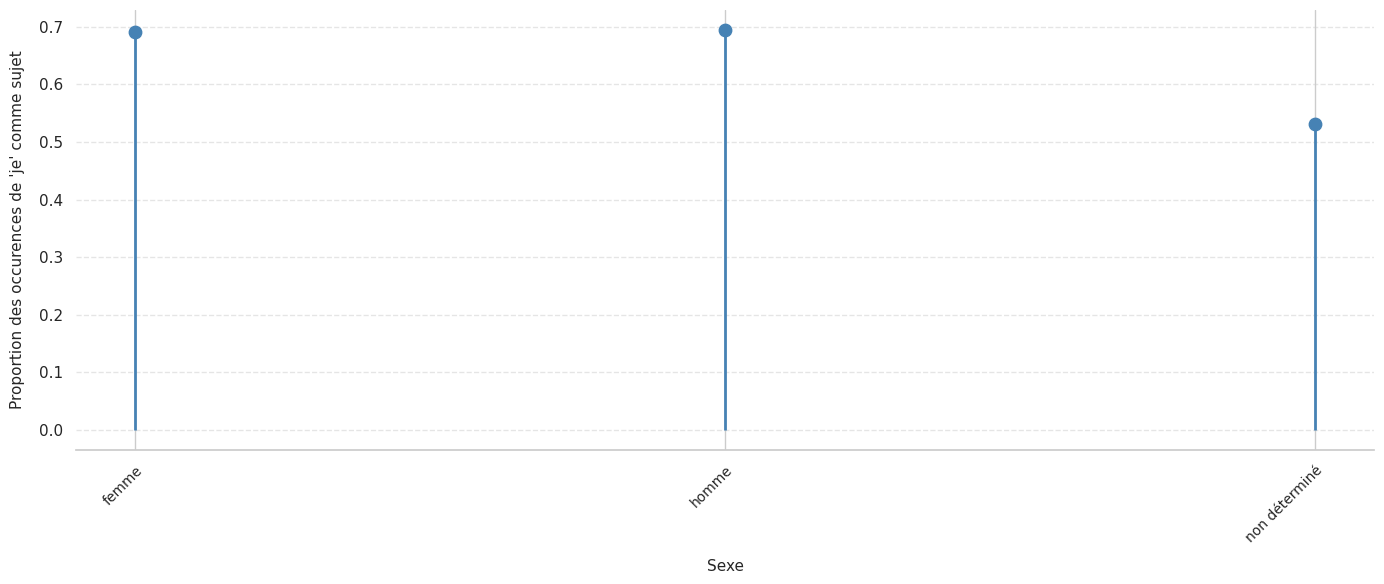

In [47]:
agg_df_je_sexe = df_je.groupby(['sexe', 'fonction']).size().unstack(fill_value=0).reset_index()
agg_df_je_sexe['non_sujet'] = (agg_df_je_sexe["COD"]+agg_df_je_sexe["COI"]+agg_df_je_sexe["apposition"]
                          +agg_df_je_sexe["autre/indéterminé"]+agg_df_je_sexe["complément du nom"]
                          +agg_df_je_sexe["coordination"])
agg_df_je_sexe["prop_sujet"] = agg_df_je_sexe["sujet"]/(agg_df_je_sexe["sujet"]+agg_df_je_sexe["non_sujet"])
agg_df_je_sexe["prop_non_sujet"] = 1-agg_df_je_sexe["prop_sujet"]


fig, ax = plt.subplots(figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1)

x = range(len(agg_df_je_sexe))
y = agg_df_je_sexe["prop_sujet"]

# Tiges
ax.vlines(x, ymin=0, ymax=y, color="steelblue", linewidth=2)
# Ronds
ax.scatter(x, y, color="steelblue", s=80, zorder=3)

ax.set_xlabel("Sexe", fontsize=11, labelpad=10)
ax.set_ylabel("Proportion des occurences de 'je' comme sujet", fontsize=11, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(
    agg_df_je_sexe["sexe"],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=10
)

ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
# Verbes
print("Verbes les plus utilisés : ", df_je_dedup['verbe'].value_counts()[:10])
print("Verbes les moins utilisés : ", df_je_dedup['verbe'].value_counts()[-10:])

Verbes les plus utilisés :  verbe
avoir        992
faire        625
proposer     603
savoir       326
souhaiter    314
croire       277
connaître    255
appeler      241
dire         219
être         216
Name: count, dtype: int64
Verbes les moins utilisés :  verbe
pencher        1
recherche      1
submerger      1
primer         1
virus          1
substituer     1
solutionner    1
sacrer         1
détailler      1
bouleverser    1
Name: count, dtype: int64


In [56]:
total_par_verbe = df_je_dedup.groupby("verbe")["verbe"].transform("count")
TOP10 = df_je_dedup['verbe'].value_counts()[:10].index.tolist()

stats2 = (
    df_je_dedup.groupby(["verbe", "parti_politique"])
    .size()
    .reset_index(name="count")
)
stats2["total_verbe"] = stats2.groupby("verbe")["count"].transform("sum")
stats2["part_du_verbe"] = (stats2["count"] / stats2["total_verbe"] * 100).round(2)


stats2_10 = stats2[stats2["verbe"].isin(TOP10)]
total_par_parti = df_je_dedup.groupby("parti_politique").size().rename("total_parti")
stats2_10 = stats2_10.merge(total_par_parti, on="parti_politique")
stats2_10["part_normalisee"] = (stats2_10["count"] / stats2_10["total_parti"] * 100).round(2)

total_global = df_je_dedup.shape[0]
stats2_10["count_pond"] = stats2_10["count"] / stats2_10["total_parti"] * total_global
stats2_10["part_pond"] = (
    stats2_10["count_pond"] / stats2_10.groupby("verbe")["count_pond"].transform("sum") * 100
).round(2)

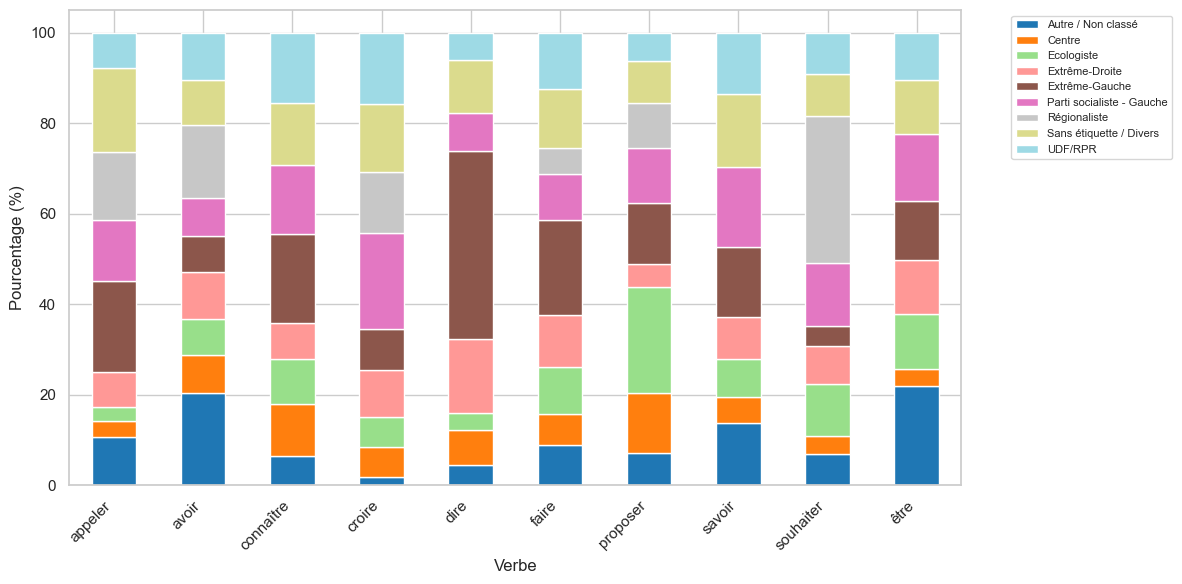

In [58]:
df_pivot = stats2_10.pivot_table(index='verbe', columns='parti_politique', values='part_pond', aggfunc='sum').fillna(0)

# Tracé
fig, ax = plt.subplots(figsize=(12, 6))
df_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Verbe')
ax.set_ylabel('Pourcentage (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
# Fréquence de chaque verbe
freq = df_je["verbe"].value_counts()

# Poids inversement proportionnel à la fréquence
df_je["poids"] = df_je["verbe"].map(freq).rdiv(1).fillna(0)

# Normalisation
df_je["poids"] = df_je["poids"] / df_je["poids"].sum()

# Échantillonnage
echantillon = df_je.sample(n=500, weights="poids", random_state=42)

In [71]:
# Complément d'échantillonnage
rows = []
for entry in echantillon.to_dict("records"):
    doc = nlp(entry["phrase"])
    for token in doc:
        rows.append({
            "texte_id"    : entry["texte_id"],
            "token_index" : token.i,
            "token"       : token.text,
            "lemme"       : token.lemma_,
            "pos"         : token.pos_,
            "dep"         : token.dep_,
            "annotation"  : ""
        })

pd.DataFrame(rows).to_csv("annotation_tokens_complémentaire.csv", index=False, encoding="utf-8-sig")

### Reprise de ce qu'il se passait avant (j'ai coupé au milieu)

### Echantillonnage de phrases à annoter

In [ ]:
PRONOMS_CIBLES = {'je', 'nous', "j'"}

def segmenter_et_extraire_features(texte_long):
    """
    Découpe un texte en phrases et identifie celles dans lesquelles apparaît un des pronoms cibles.
    Retourne une liste de dictionnaires : {'texte': phrase, 'doc_id': id}
    """
    doc = nlp(texte_long)
    phrases_interessantes = []
    
    for sent in doc.sents:
            
        sent_text = sent.text.strip()
        has_pronom = False
        pronoms_in_sent = []
        
        for token in sent:
            t_lower = token.text.lower()
            l_lower = token.lemma_.lower()
            
            if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
                has_pronom = True
                pronoms_in_sent.append(t_lower)
            
            if has_pronom : 
                phrases_interessantes.append({
                    "texte": sent_text,
                    "pronoms": pronoms_in_sent
                })
                
    return phrases_interessantes


In [28]:
len(transcriptions['texte_nettoye'])

5936

In [29]:
sample_texts = transcriptions[['texte_nettoye', 'id']].sample(n = 1000)

print("Segmentation des textes en phrases...")
toutes_les_phrases = []

for idx, texte in sample_texts['texte_nettoye'].items():
    if isinstance(texte, str) and len(texte) > 10:
        phrases = segmenter_et_extraire_features(texte)
        id_text = sample_texts['id'][idx]
        for p in phrases:
            p['doc_id'] = id_text
        toutes_les_phrases.extend(phrases)

print(f"Total de phrases candidates extraites : {len(toutes_les_phrases)}")


Segmentation des textes en phrases...
Total de phrases candidates extraites : 151893


In [ ]:
echantillon_final = []

list_je = [p for p in toutes_les_phrases if ('je' in p['pronoms'] or "j'" in p['pronoms'] )]

list_nous = [p for p in toutes_les_phrases if 'nous' in p['pronoms']]

#list_vous = [p for p in toutes_les_phrases if 'vous' in p['pronoms'] ]

print("Je :", len(list_je))
#print("Vous : ", len(list_vous))
print("Nous : ", len(list_nous))

Je : 59534
Vous :  59748
Nous :  68032


In [ ]:
import random 
random.shuffle(list_je)
echantillon_final.extend(list_je[:300])

random.shuffle(list_nous)
echantillon_final.extend([p for p in list_nous if p not in echantillon_final][:300])

#random.shuffle(list_vous)
#echantillon_final.extend([p for p in list_vous if p not in echantillon_final][:300])

print(f"Taille de l'échantillon final à annoter : {len(echantillon_final)} phrases.")

Taille de l'échantillon final à annoter : 900 phrases.


In [ ]:
# On pré-annote les données, comme ça on n'aura plus qu'à repasser dessus, corriger et compléter.
def phrase_vers_lignes_tokens(phrase_data, phrase_id):
    '''
    phrases_data : dictionnaire contenant l'ensemble des phrases à annoter (sous la clé texte).
    Retourne une liste de dictionnaires avec des suggestions d'annotations
    '''
    texte = phrase_data['texte']
    doc = nlp(texte)
    rows = []
    
    verbe_types = {} # ACT/ETAT
    pronoms_roles = {} # SUJ/OBJ
    
    for token in doc:
        t_lower = token.text.lower()
        l_lower = token.lemma_.lower()
        
        # Rôle du pronom dans la hrase
        if t_lower in PRONOMS_CIBLES and token.pos_ == "PRON":
            if token.dep_ in ("nsubj", "nsubjpass"):
                pronoms_roles[token.i] = "SUJ"
            elif token.dep_ in ("dobj", "obj", "iobj", "obl"):
                pronoms_roles[token.i] = "OBJ"
        
        # Type de verbe
        if token.pos_ in ("VERB", "AUX"):

            is_modal = l_lower in VERBES_MODAUX  # True/False
            
            if is_modal:
                for child in token.children:  # On cherche si on a un verbe parmi les enfants (penser à 'nous devons agir')
                    if child.pos_ == "VERB":
                        child_lemme = child.lemma_.lower()
                        child_is_etat_bool = child_lemme in VERBES_ETAT
                        verbe_types[child.i] = "ETAT" if child_is_etat_bool else "ACT"
                
            else:
                is_etat_bool = l_lower in VERBES_ETAT
                verbe_types[token.i] = "ETAT" if is_etat_bool else "ACT"

    # Construction des lignes
    for token in doc:
        label_suggere = "O"
        
        if token.i in pronoms_roles:
            label_suggere = f"B-PRON_{pronoms_roles[token.i]}"
        
        if token.i in verbe_types:
            if label_suggere == "O":
                label_suggere = f"B-VERB_{verbe_types[token.i]}"
        
        rows.append({
            "phrase_id" : phrase_id,
            "doc_id_origine": phrase_data['doc_id'],
            "pronoms": phrase_data['pronoms'],
            "token_text": token.text,
            "lemma": token.lemma_,
            "pos": token.pos_,
            "dep": token.dep_,
            "suggestion_label": label_suggere,
            "label_final": "" 
        })
        
    return rows

In [ ]:
# Génération du fichier à annoter

rows_csv = []
for i, phrase_data in enumerate(echantillon_final):
    rows = phrase_vers_lignes_tokens(phrase_data, i)
    rows_csv.extend(rows)

annotate_csv = pd.DataFrame(rows_csv)

annotate_csv.to_csv("annotation_token_strategy_new.csv", index=False, encoding="utf-8")

print("\nAperçu des 10 premières lignes :")
print(annotate_csv[['token_text', 'suggestion_label', 'label_final']].head(10))


Aperçu des 10 premières lignes :
   token_text suggestion_label label_final
0          je       B-PRON_SUJ            
1       pense      B-VERB_ETAT            
2   également                O            
3  nécessaire                O            
4         qu'                O            
5          un                O            
6        plus                O            
7       grand                O            
8      nombre                O            
9          de                O            


### Entrainement du modèle

In [39]:
# Chargement des données et gestion des problèmes d'encodage
annotations1 = pd.read_csv("annotations/annotation_token_strategy_annotations.csv", sep=";",encoding="latin-1")
annotations1 = annotations1.apply(lambda col: col.map(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x))
annotations1 = annotations1.dropna()

annotations2 = pd.read_csv("annotations/annotation_tokens_complémentaire.csv", sep=";")
annotations2 = annotations2.rename(columns = {"token":"token_text", 
                                    'Unnamed: 0':"phrase_id", 
                                    "text_id":"doc_id_origine"})
annotations2 = annotations2.dropna()

# Erreurs de frappe constatées a posteriori
annotations1["label_concret"] = annotations1["label_concret"].replace('B-VERB_CONRET', 'B-VERB_CONCRET')
annotations1["label_concret"] = annotations1["label_concret"].replace('B-VERB_CONCRET ', 'B-VERB_CONCRET')
annotations1["label_concret"] = annotations1["label_concret"].replace('I-VERB-CONCRET', 'I-VERB_CONCRET')
annotations1["label_concret"] = annotations1["label_concret"].replace('E-VERB-CONCRET', 'E-VERB_CONCRET')
annotations1["label_concret"] = annotations1["label_concret"].replace('B-VERB-CONTEXTE', 'B-VERB_CONTEXTE') 

annotations1["label_discours"] = annotations1["label_discours"].replace('B-ACT', 'B-VERB_ACT')  
annotations1["label_discours"] = annotations1["label_discours"].replace('I-VERB_ETA', 'I-VERB_ETAT') 
annotations1["label_discours"] = annotations1["label_discours"].replace('V-VERB_ACT', 'B-VERB_ACT')

textes_annotes = pd.unique(annotations1["doc_id_origine"])


In [40]:
# Création du df de travail pour le label_concret
annotations_work_concret1 = annotations1[["phrase_id", "token_text", "label_concret"]]
annotations_work_concret2 = annotations2[["phrase_id", "token_text", "label_concret"]]

# Clé identifiant le fichier d'origine
annotations_work_concret1['_src'] = 0
annotations_work_concret2['_src'] = 1

df_concat_concret = pd.concat([annotations_work_concret1, annotations_work_concret2], ignore_index=True)

# Renuméroter les 'phrase_id' en tenant compte de la source
df_concat_concret['phrase_id'] =(
    df_concat_concret.groupby(['_src', 'phrase_id'], sort=False)
    .ngroup() + 1
)

annotations_work_concret = df_concat_concret.groupby("phrase_id").agg(
    token_text=("token_text", list),
    label_concret=("label_concret", lambda x: [v[0] if isinstance(v, list) else v for v in x])
).reset_index()

/tmp/ipykernel_13338/3142100308.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotations_work_concret1['_src'] = 0
/tmp/ipykernel_13338/3142100308.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotations_work_concret2['_src'] = 1


In [41]:
# Préparation pour avoir une partie train et une partie test

def split_by_phrase_id(df, col_tag, train_ratio=0.8, val_ratio=0.1, seed=42):
    
    sentences = df.to_dict(orient="records")

    random.seed(seed)
    random.shuffle(sentences)

    n = len(sentences)

    def density_bucket(example):
        n_entities = sum(1 for t in example[col_tag] if t.startswith("B-"))
        if n_entities == 0:
            return 0
        elif n_entities <= 2:
            return 1
        else:
            return 2

    buckets = {0: [], 1: [], 2: []}
    for _, ex in df.iterrows():
        buckets[density_bucket(ex)].append(ex)

    train, val, test = [], [], []

    for bucket_data in buckets.values():
        random.shuffle(bucket_data)
        n = len(bucket_data)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        train += bucket_data[:n_train]
        val   += bucket_data[n_train:n_train + n_val]
        test  += bucket_data[n_train + n_val:]

    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)

    print(f"Train : {len(train)} phrases")
    print(f"Val   : {len(val)} phrases")
    print(f"Test  : {len(test)} phrases")

    return train, val, test

#### Label concret

In [42]:
train, val, test = split_by_phrase_id(annotations_work_concret, "label_concret")

Train : 526 phrases
Val   : 64 phrases
Test  : 69 phrases


In [43]:
labels_conc = list({t for row in annotations_work_concret["label_concret"] for t in row})
num_labels_conc = len(labels_conc)
id2label = {id:label for id, label in enumerate(labels_conc)}
label2id = {label:id  for id, label in enumerate(labels_conc)}

def encode_labels(example, col_tag):
    example[col_tag] = [label2id[t] for t in example[col_tag]]
    return example

COL_TAG = "label_concret"
train = [row.to_dict() for row in train]
test  = [row.to_dict() for row in test]
val   = [row.to_dict() for row in val]

train_processed = [encode_labels(ex, COL_TAG) for ex in train]
test_processed = [encode_labels(ex, COL_TAG) for ex in test]
val_processed = [encode_labels(ex, COL_TAG) for ex in val]

train_dataset = Dataset.from_list(train_processed)
test_dataset = Dataset.from_list(test_processed)
val_dataset = Dataset.from_list(val_processed)

dataset = DatasetDict({"train": train_dataset, "test":test_dataset, "validation": val_dataset})

In [44]:
MODEL_NAME = "camembert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["token_text"],
        col_tag = COL_TAG,
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128,
    )

    all_labels = []
    for i, labels in enumerate(examples[COL_TAG]):
        word_ids = tokenized.word_ids(batch_index=i)
        print(f"Nb labels: {len(labels)}, max word_id: {max(w for w in word_ids if w is not None)}")
        aligned_labels = []
        prev_word_id = None

        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)
            elif word_id != prev_word_id:
                aligned_labels.append(labels[word_id])
            else:
                aligned_labels.append(-100)
            prev_word_id = word_id

        all_labels.append(aligned_labels)

    tokenized["labels"] = all_labels
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

Map: 100%|██████████| 526/526 [00:00<00:00, 6525.78 examples/s]


Nb labels: 35, max word_id: 34
Nb labels: 5, max word_id: 4
Nb labels: 19, max word_id: 18
Nb labels: 113, max word_id: 83
Nb labels: 23, max word_id: 22
Nb labels: 17, max word_id: 16
Nb labels: 38, max word_id: 37
Nb labels: 43, max word_id: 42
Nb labels: 72, max word_id: 71
Nb labels: 13, max word_id: 12
Nb labels: 27, max word_id: 26
Nb labels: 14, max word_id: 13
Nb labels: 23, max word_id: 22
Nb labels: 45, max word_id: 44
Nb labels: 15, max word_id: 14
Nb labels: 39, max word_id: 38
Nb labels: 50, max word_id: 49
Nb labels: 26, max word_id: 25
Nb labels: 45, max word_id: 44
Nb labels: 42, max word_id: 41
Nb labels: 35, max word_id: 34
Nb labels: 27, max word_id: 26
Nb labels: 44, max word_id: 43
Nb labels: 45, max word_id: 44
Nb labels: 43, max word_id: 42
Nb labels: 29, max word_id: 28
Nb labels: 24, max word_id: 23
Nb labels: 14, max word_id: 13
Nb labels: 11, max word_id: 10
Nb labels: 18, max word_id: 17
Nb labels: 20, max word_id: 19
Nb labels: 9, max word_id: 8
Nb labels: 

Map: 100%|██████████| 69/69 [00:00<00:00, 4478.53 examples/s]


Nb labels: 22, max word_id: 21
Nb labels: 83, max word_id: 82
Nb labels: 28, max word_id: 27
Nb labels: 20, max word_id: 19
Nb labels: 20, max word_id: 19
Nb labels: 55, max word_id: 54
Nb labels: 18, max word_id: 17
Nb labels: 43, max word_id: 42
Nb labels: 15, max word_id: 14
Nb labels: 9, max word_id: 8
Nb labels: 39, max word_id: 38
Nb labels: 22, max word_id: 21
Nb labels: 14, max word_id: 13
Nb labels: 31, max word_id: 30
Nb labels: 24, max word_id: 23
Nb labels: 52, max word_id: 51
Nb labels: 30, max word_id: 29
Nb labels: 22, max word_id: 21
Nb labels: 53, max word_id: 52
Nb labels: 22, max word_id: 21
Nb labels: 44, max word_id: 43
Nb labels: 19, max word_id: 18
Nb labels: 27, max word_id: 26
Nb labels: 18, max word_id: 17
Nb labels: 47, max word_id: 46
Nb labels: 110, max word_id: 109
Nb labels: 71, max word_id: 70
Nb labels: 44, max word_id: 43
Nb labels: 31, max word_id: 30
Nb labels: 6, max word_id: 5
Nb labels: 21, max word_id: 20
Nb labels: 9, max word_id: 8
Nb labels: 2

Map: 100%|██████████| 64/64 [00:00<00:00, 3985.32 examples/s]

Nb labels: 37, max word_id: 36
Nb labels: 36, max word_id: 35
Nb labels: 27, max word_id: 26
Nb labels: 26, max word_id: 25
Nb labels: 25, max word_id: 24
Nb labels: 16, max word_id: 15
Nb labels: 58, max word_id: 57
Nb labels: 53, max word_id: 52
Nb labels: 19, max word_id: 18
Nb labels: 34, max word_id: 33
Nb labels: 30, max word_id: 29
Nb labels: 19, max word_id: 18
Nb labels: 110, max word_id: 96
Nb labels: 10, max word_id: 9
Nb labels: 40, max word_id: 39
Nb labels: 28, max word_id: 27
Nb labels: 35, max word_id: 34
Nb labels: 40, max word_id: 39
Nb labels: 11, max word_id: 10
Nb labels: 34, max word_id: 33
Nb labels: 38, max word_id: 37
Nb labels: 27, max word_id: 26
Nb labels: 32, max word_id: 31
Nb labels: 65, max word_id: 64
Nb labels: 31, max word_id: 30
Nb labels: 5, max word_id: 4
Nb labels: 22, max word_id: 21
Nb labels: 43, max word_id: 42
Nb labels: 71, max word_id: 70
Nb labels: 24, max word_id: 23
Nb labels: 45, max word_id: 44
Nb labels: 134, max word_id: 100
Nb label

In [45]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels_conc),
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6768.33it/s]
[transformers] CamembertForTokenClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
# Métrique seqeval (F1 par entité)
seqeval = evaluate.load("seqeval")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(predictions, labels):
        p_row, l_row = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100: 
                p_row.append(id2label[p])
                l_row.append(id2label[l])
        true_preds.append(p_row)
        true_labels.append(l_row)

    results = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

all_labels_flat = [t for ex in train for t in ex["label_concret"]]
counts = Counter(all_labels_flat)
total  = sum(counts.values())
weights = torch.zeros(num_labels_conc)
for label_id, count in counts.items():
    weights[label_id] = total / (num_labels_conc * count)
print("Poids par classe :", {id2label[i]: round(w.item(), 2) for i, w in enumerate(weights)})
weights = torch.clamp(weights, max=10.0)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=weights.to(logits.device),
            ignore_index=-100
        )
        loss = loss_fct(logits.view(-1, num_labels_conc), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Collator : gère le padding dynamique
data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir="./camembert",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    warmup_ratio = 0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=1,
    fp16=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

# Sauvegarde du meilleur modèle
trainer.save_model("./camembert-final")
tokenizer.save_pretrained("./camembert-final")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Poids par classe : {'O': 0.11, 'B-VERB_CONCRET': 6.1, 'E-VERB_CONCRET': 26.13, 'E-VERB_CONTEXTE': 48.82, 'B-VERB_CONTEXTE': 4.55, 'B-OBJ': 14.16, 'I-VERB_CONCRET': 10.48, 'B-VERB_CINCRET': 1855.0, 'B-SUJ': 2.77, 'I-VERB_CONTEXTE': 18.01}


/opt/python/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.453583,1.244492,0.271300,0.675978,0.387200,0.766302
2,0.747691,0.866401,0.383721,0.737430,0.504780,0.881733
3,0.528708,0.768322,0.460714,0.720670,0.562092,0.907655
4,0.840159,0.664618,0.588477,0.798883,0.677725,0.937627
5,0.456368,0.700995,0.647059,0.798883,0.715000,0.951802


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.38it/s]
/opt/python/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.58it/s]
/opt/python/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.45it/s]
/opt/python/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s]
/opt/python/lib/python3.13/site-packages/torch/utils/dat

('./camembert-final/tokenizer_config.json', './camembert-final/tokenizer.json')

#### Mise en forme des données pour appliquer le modèle

In [47]:
def chunk_by_tokens(text, tokenizer, max_tokens=300, overlap=50):
    tokens = tokenizer.tokenize(text)

    chunks = []
    start = 0

    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]

        chunk_text = tokenizer.convert_tokens_to_string(chunk_tokens)
        chunks.append(chunk_text)

        start = end - overlap

    return chunks

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=2)[0].tolist()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    labels = [model.config.id2label[p] for p in preds]

    return list(zip(tokens, labels))

def predict_long_text(text):
    chunks = chunk_by_tokens(text, tokenizer)
    print(f"Nombre de chunks: {len(chunks)}")
    all_preds = []

    for chunk in chunks:
        preds = predict(chunk)
        all_preds.extend(preds)

    return all_preds

In [48]:
tokenizer = AutoTokenizer.from_pretrained("./camembert-final")
model = AutoModelForTokenClassification.from_pretrained("./camembert-final")

model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7204.90it/s]


CamembertForTokenClassification(
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=768, out_features=10, bias=True)
  (roberta): CamembertModel(
    (embeddings): CamembertEmbeddings(
      (word_embeddings): Embedding(32005, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): CamembertEncoder(
      (layer): ModuleList(
        (0-11): 12 x CamembertLayer(
          (attention): CamembertAttention(
            (self): CamembertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
        

In [49]:
# Test
for _, row in tqdm(transcriptions.head(15).iterrows()):
    text = row["text"]
    preds = predict_long_text(text)
    print(preds[:10])

0it [00:00, ?it/s][transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1335 > 512). Running this sequence through the model will result in indexing errors


Nombre de chunks: 6


1it [00:01,  1.49s/it]

[('<s>', 'O'), ('▁Département', 'O'), ('▁de', 'O'), ('▁Seine', 'O'), ('-', 'O'), ('Maritime', 'O'), ('▁-', 'O'), ('▁12', 'O'), ('ème', 'O'), ('▁', 'O')]
Nombre de chunks: 5


2it [00:02,  1.43s/it]

...

[('<s>', 'O'), ('▁2°', 'O'), ('▁C', 'O'), ('IRC', 'O'), ('ONS', 'O'), ('CR', 'O'), ('IP', 'O'), ('TION', 'O'), ('▁DU', 'O'), ('▁', 'O')]
Nombre de chunks: 4


14it [00:15,  1.11s/it]

[('<s>', 'O'), ('▁Sciences', 'O'), ('▁Po', 'O'), ('▁/', 'O'), ('▁fonds', 'O'), ('▁C', 'O'), ('EV', 'O'), ('IP', 'O'), ('OF', 'O'), ('▁Département', 'O')]
Nombre de chunks: 6


15it [00:17,  1.16s/it]

[('<s>', 'O'), ('▁Sciences', 'O'), ('▁Po', 'O'), ('▁/', 'O'), ('▁fonds', 'O'), ('▁C', 'O'), ('EV', 'O'), ('IP', 'O'), ('OF', 'O'), ('▁', 'O')]


In [ ]:
results = []

for _, row in tqdm(transcriptions.iterrows()):
    text = row["text"]

    preds = predict_long_text(text)  

    results.append({
        **row.to_dict(),
        "predictions": preds
    })

In [ ]:
df_results = pd.to_csv("./outputs/predictions_camembert_final.csv")


## Final results

In [ ]:
df_results = pd.read_csv("./outputs/predictions_camembert_final.csv")
df_results.head(5)

In [117]:
df_results = pd.read_parquet("./outputs/predictions_camembert_final.parquet", columns=["id", "titulaire-sexe", "predictions"])
def safe_parse(x):
    try:
        return ast.literal_eval(x)
    except:
        return None

df_results["predictions"] = df_results["predictions"].apply(safe_parse)
#df_results.head(5)

In [118]:
df_results = df_results.explode("predictions")
df_results["label"] = df_results["predictions"].apply(lambda x: x[1])


In [127]:
df_results["Concret"] = df_results["label"].isin(["B-VERB_CONCRET", "E-VERB_CONCRET", "B-VERB_CONCRET"]).astype(int)
df_results["Contexte"] = df_results["label"].isin(["B-VERB_CONTEXTE", "E-VERB_CONTEXTE", "B-VERB_CONTEXTE"]).astype(int)
results = df_results[["id", "titulaire-sexe", "Concret", "Contexte"]]
results = results.groupby(["id", "titulaire-sexe"], as_index=False).agg({
    "Concret": "sum",
    "Contexte": "sum"
})


In [130]:
results_enrichi = results.merge(
    data[["id", "departement", "titulaire-profession"]],
    on="id",
    how="left"
    )
results_enrichi["Concret_Contexte"] = results["Concret"] / results["Contexte"]
results_enrichi

,id,titulaire-sexe,Concret,Contexte,departement,titulaire-profession,Concret_Contexte
0,EL189_L_1993_03_001_01_1_PF_01,homme,57,8,01,artisan graveur ornemaniste,7.125000
1,EL189_L_1993_03_001_01_1_PF_02,homme,12,25,01,ouvrier Renault Véhicules industriels,0.480000
2,EL189_L_1993_03_001_01_1_PF_03,homme,13,14,01,non mentionné,0.928571
3,EL189_L_1993_03_001_01_1_PF_04,homme,11,36,01,ouvrier métallurgiste,0.305556
4,EL189_L_1993_03_001_01_1_PF_05,homme,2,1,01,professeur économie,2.000000
...,...,...,...,...,...,...,...
5832,EL198_L_1993_03_095_09_1_PF_10,homme,24,19,95,non mentionné,1.263158
5833,EL198_L_1993_03_095_09_1_PF_11,femme,12,28,95,non mentionné,0.428571
5834,EL198_L_1993_03_095_09_1_PF_12,non déterminé,6,5,95,non mentionné,1.200000
5835,EL198_L_1993_03_095_09_2_PF_01,homme,1,5,95,non mentionné,0.200000


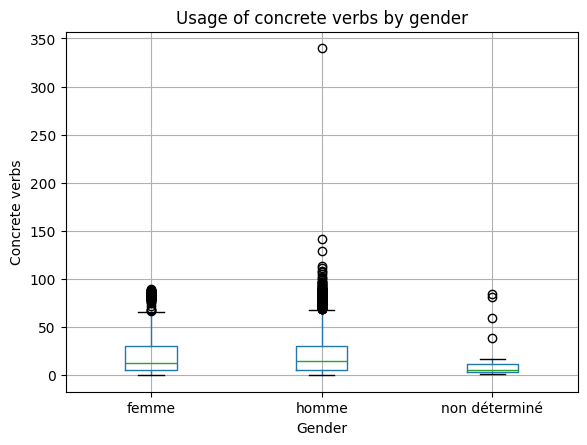

In [139]:
results_enrichi = results_enrichi.dropna(subset=["titulaire-sexe", "Concret"])

results_enrichi.boxplot(column="Concret", by="titulaire-sexe")

plt.title("Usage of concrete verbs by gender")
plt.suptitle("") 
plt.xlabel("Gender")
plt.ylabel("Concrete verbs")

#plt.savefig("figures/CC Gender")
plt.show()

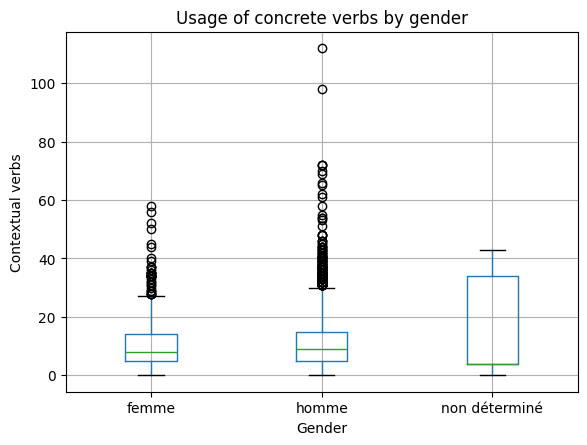

In [141]:
results_enrichi = results_enrichi.dropna(subset=["titulaire-sexe", "Contexte"])

results_enrichi.boxplot(column="Contexte", by="titulaire-sexe")

plt.title("Usage of concrete verbs by gender")
plt.suptitle("") 
plt.xlabel("Gender")
plt.ylabel("Contextual verbs")

#plt.savefig("figures/CC Gender")
plt.show()

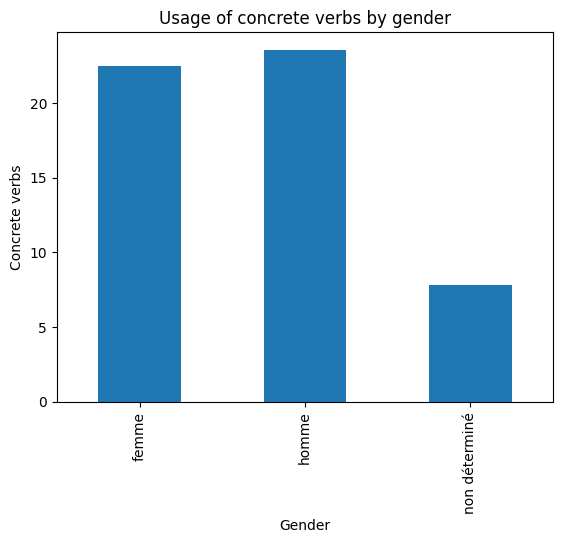

In [145]:
results_enrichi.groupby("titulaire-sexe")["Concret"].mean().plot(kind="bar")

plt.title("Usage of concrete verbs by gender")
plt.suptitle("") 
plt.xlabel("Gender")
plt.ylabel("Concrete verbs")

#plt.show()
plt.savefig("figures/Concrete verbs Gender")

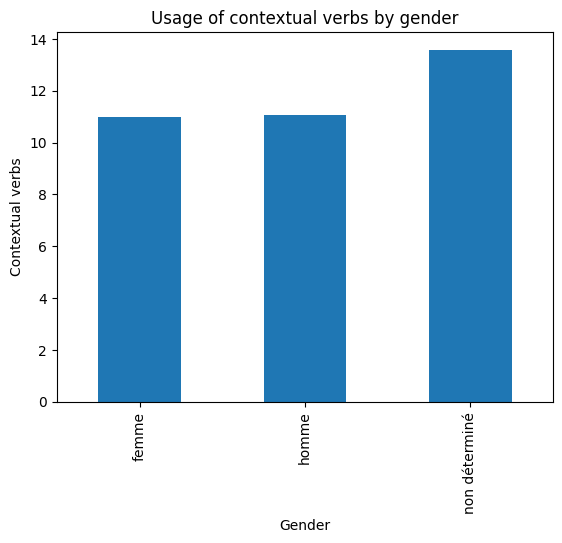

In [147]:
results_enrichi.groupby("titulaire-sexe")["Contexte"].mean().plot(kind="bar")
plt.title("Usage of contextual verbs by gender")
plt.suptitle("") 
plt.xlabel("Gender")
plt.ylabel("Contextual verbs")

#plt.show()
plt.savefig("figures/Contextual verbs Gender")

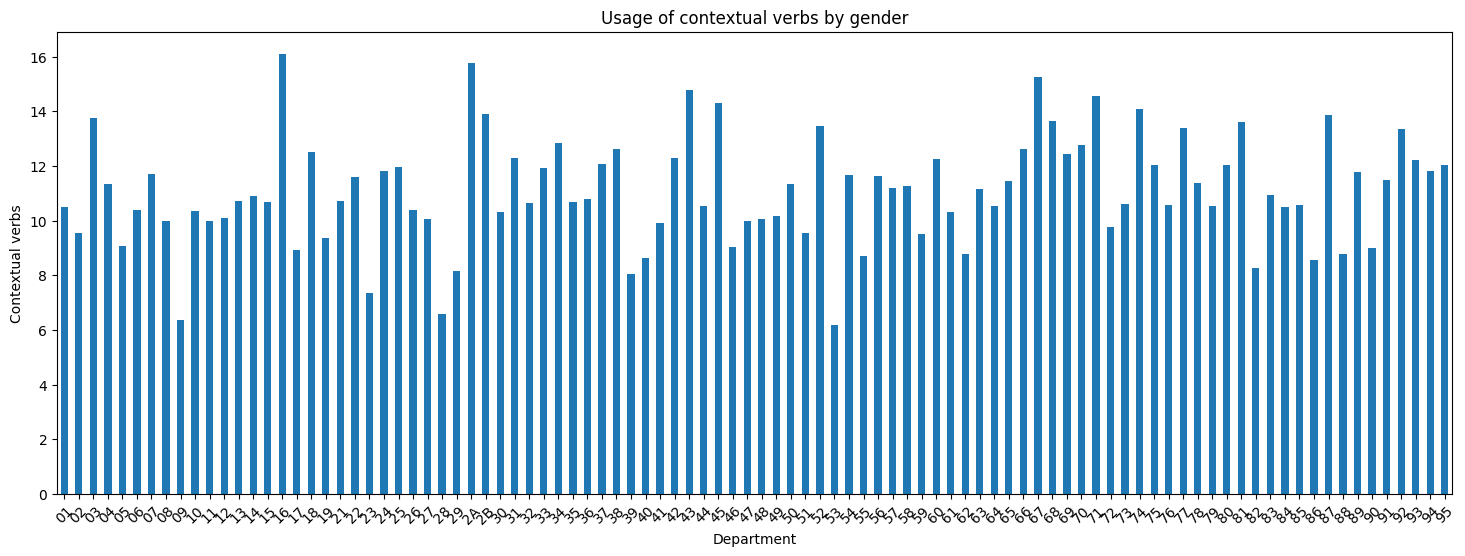

In [ ]:
plt.figure(figsize=(18, 6))
results_enrichi.groupby("departement")["Contexte"].mean().plot(kind="bar")
plt.title("Usage of contextual verbs by department")
plt.suptitle("")
plt.xticks(rotation=45) 
plt.xlabel("Department")
plt.ylabel("Contextual verbs")

#plt.show()
plt.savefig("figures/Contextual verbs DPT")

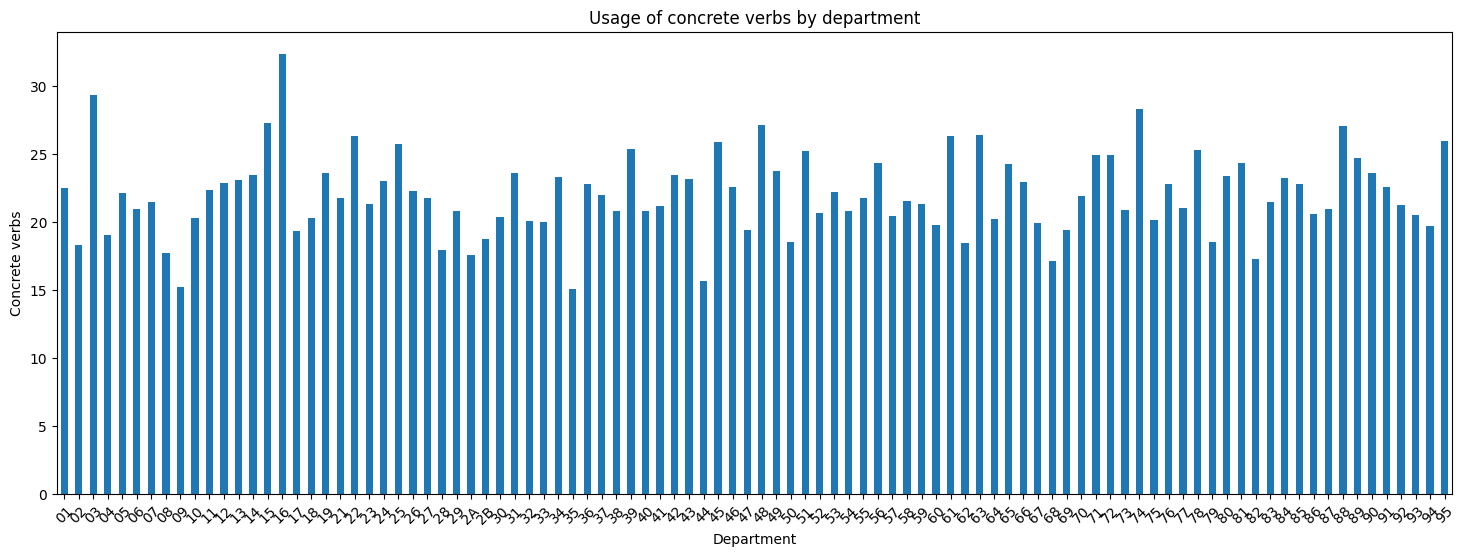

In [151]:
plt.figure(figsize=(18, 6))
results_enrichi.groupby("departement")["Concret"].mean().plot(kind="bar")
plt.title("Usage of concrete verbs by department")
plt.suptitle("")
plt.xticks(rotation=45) 
plt.xlabel("Department")
plt.ylabel("Concrete verbs")

#plt.show()
plt.savefig("figures/Concrete verbs DPT")

In [153]:
results_enrichi

,id,titulaire-sexe,Concret,Contexte,departement,titulaire-profession,Concret_Contexte
0,EL189_L_1993_03_001_01_1_PF_01,homme,57,8,01,artisan graveur ornemaniste,7.125000
1,EL189_L_1993_03_001_01_1_PF_02,homme,12,25,01,ouvrier Renault Véhicules industriels,0.480000
2,EL189_L_1993_03_001_01_1_PF_03,homme,13,14,01,non mentionné,0.928571
3,EL189_L_1993_03_001_01_1_PF_04,homme,11,36,01,ouvrier métallurgiste,0.305556
4,EL189_L_1993_03_001_01_1_PF_05,homme,2,1,01,professeur économie,2.000000
...,...,...,...,...,...,...,...
5832,EL198_L_1993_03_095_09_1_PF_10,homme,24,19,95,non mentionné,1.263158
5833,EL198_L_1993_03_095_09_1_PF_11,femme,12,28,95,non mentionné,0.428571
5834,EL198_L_1993_03_095_09_1_PF_12,non déterminé,6,5,95,non mentionné,1.200000
5835,EL198_L_1993_03_095_09_2_PF_01,homme,1,5,95,non mentionné,0.200000
